In [6]:
"""
Topology optimization of a 90-degree Si3N4 waveguide bend in Tidy3D.

- Core: Si3N4 (Luke2015PMLStable), 800 nm thick
- Cladding: SiO2 (Palik_Lossless)
- Waveguide width at ports: 1.2 um
- Mode: fundamental TE (TE0)
- Wavelength: 1550 nm
- Initial guess for the design region: rasterized from 'Bend.gds' (layer 2)

Runs on the Tidy3D notebook platform. Requires 'gdstk' and 'autograd'
(both installed by default in the Tidy3D online notebook environment).

Upload Bend.gds to the same directory as this notebook before running.
"""

import autograd
import autograd.numpy as anp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

import gdstk
import tidy3d as td
import tidy3d.web as web

from tidy3d.plugins.autograd import (
    make_filter_and_project,
    make_erosion_dilation_penalty,
    adam,
    apply_updates,
)

In [7]:
# =============================================================================
# 1. GLOBAL PARAMETERS
# =============================================================================

# --- Wavelength / frequency ---
wvl0 = 1.55                          # design wavelength (um)
freq0 = td.C_0 / wvl0                # design frequency
fwidth = freq0 / 10.0                # source bandwidth (~10 % of center)

# --- Geometry ---
wg_width = 1.2                       # waveguide width at the ports (um)
thick = 0.8                          # Si3N4 slab thickness (um)

# --- Materials ---
SiN = td.material_library["Si3N4"]["Luke2015PMLStable"]
SiO2 = td.material_library["SiO2"]["Palik_Lossless"]

# Representative permittivities at the design wavelength (for gridding and
# for mapping the density field 0->1 into the permittivity range).
eps_sin = SiN.eps_model(freq0).real
eps_sio2 = SiO2.eps_model(freq0).real

# --- Fabrication / optimization ---
# Typical Si3N4 photolithography constraints: ~200 nm minimum feature size.
radius = 0.2                         # min feature radius for filter/penalty (um)

# The DESIGN pixel grid is coarser than the FDTD grid: a 60 nm pixel is fine
# enough to resolve features >= 2 * radius with the conic filter, and keeps
# the design region small enough to be tractable (~350x350 pixels for a
# 20.6 um bend).  The FDTD mesh itself is set by `min_steps_per_wvl` below
# plus a MeshOverrideStructure that matches the pixel size.
pixel_size = 0.06                    # design-region pixel size (um)

# Auto-mesh: steps per wavelength inside the highest-index material.
min_steps_per_wvl = 25

In [8]:
# =============================================================================
# 2. READ THE INITIAL BEND FROM THE GDS FILE
# =============================================================================
#
# The GDS file has three polygons on layer (2, 0):
#   Polygon 0: the curved 90-deg bend itself (≈938 vertices), bbox (-4.30, -4.30)
#              to (16.30, 16.30), so about 20.6 x 20.6 um.
#   Polygon 1: a rectangular stub at x in [15.1, 16.3], y in [-16.3, -4.3]
#              -- the input port going down.
#   Polygon 2: a rectangular stub at x in [-16.3, -4.3], y in [15.1, 16.3]
#              -- the output port going left.
#
# We treat Polygon 0 as the design region (we will re-create it as a density
# array), and Polygons 1 & 2 as static input/output waveguides.

GDS_FILE = "Bend.gds"
GDS_LAYER = 2
GDS_DATATYPE = 0


def load_gds_polygons(path, layer, datatype):
    """Return a list of (N, 2) arrays, one per polygon on the given layer."""
    lib = gdstk.read_gds(path)
    top = max(lib.cells, key=lambda c: len(c.polygons) + len(c.references))
    flat = top.copy("flat_tmp", deep_copy=True)
    flat.flatten()
    polys = [
        np.asarray(p.points)
        for p in flat.polygons
        if p.layer == layer and p.datatype == datatype
    ]
    return polys


polys = load_gds_polygons(GDS_FILE, GDS_LAYER, GDS_DATATYPE)

# Sort polygons by vertex count: the curvy bend has by far the most vertices.
polys_sorted = sorted(polys, key=lambda p: -len(p))
bend_polygon = polys_sorted[0]
straight_polygons = polys_sorted[1:]

# Design region bounding box from the bend polygon, inflated by half a pixel
# so the rasterized grid covers the shape cleanly.
pad = 0.5 * pixel_size
x_min, y_min = bend_polygon[:, 0].min() - pad, bend_polygon[:, 1].min() - pad
x_max, y_max = bend_polygon[:, 0].max() + pad, bend_polygon[:, 1].max() + pad

design_center = ((x_min + x_max) / 2.0, (y_min + y_max) / 2.0, 0.0)
design_size_xy = (x_max - x_min, y_max - y_min)

# --- Rasterize the bend polygon into a density array ---------------------
# The design region lives on a regular grid with spacing `pixel_size`.
# Pixel (i, j) corresponds to physical position
#     x = x_min + (i + 0.5) * pixel_size
#     y = y_min + (j + 0.5) * pixel_size.
nx = int(np.round(design_size_xy[0] / pixel_size))
ny = int(np.round(design_size_xy[1] / pixel_size))
xs = x_min + (np.arange(nx) + 0.5) * pixel_size
ys = y_min + (np.arange(ny) + 0.5) * pixel_size
XX, YY = np.meshgrid(xs, ys, indexing="ij")

# gdstk.inside() can be finicky with a single polygon arg; use matplotlib's
# Path.contains_points for a robust, fast rasterization.
points = np.stack([XX.ravel(), YY.ravel()], axis=1)
mask = MplPath(bend_polygon).contains_points(points)
init_density = mask.reshape(nx, ny).astype(float)
# shape the density array as (nx, ny, 1) to match the (x, y, z) layout Tidy3D
# expects for a 2D topology region.
init_density = init_density[:, :, None]

# The filter+project round-trip will shrink sharp edges slightly; biasing the
# initial parameters a bit (0.5 at the edge, full 0/1 in the bulk) makes the
# optimizer's first FDTD run behave like the nominal bend.
params_init = 0.5 + 0.5 * (2.0 * init_density - 1.0) * 0.9

print(f"Design region: {design_size_xy[0]:.2f} x {design_size_xy[1]:.2f} um")
print(f"Pixel grid: {nx} x {ny} (pixel_size = {pixel_size*1e3:.1f} nm)")
print(f"Initial fill fraction: {init_density.mean():.3f}")

Design region: 20.66 x 20.66 um
Pixel grid: 344 x 344 (pixel_size = 60.0 nm)
Initial fill fraction: 0.095


In [9]:
# =============================================================================
# 3. STATIC STRUCTURES: input/output waveguides + cladding
# =============================================================================

def polygon_to_structure(points_xy, medium):
    """Turn a 2D polygon into a Tidy3D PolySlab Structure (extruded in z)."""
    geom = td.PolySlab(
        vertices=points_xy.tolist(),
        slab_bounds=(-thick / 2.0, thick / 2.0),
        axis=2,
    )
    return td.Structure(geometry=geom, medium=medium)


# The rectangular port stubs — we extend them a bit to make sure they cross
# the simulation boundary cleanly.
EXTEND = 2.0  # um of extra length outside the design region


def extend_stub(points_xy):
    """Extend a rectangular stub outward along its long axis by EXTEND um."""
    pts = np.array(points_xy)
    dx = pts[:, 0].max() - pts[:, 0].min()
    dy = pts[:, 1].max() - pts[:, 1].min()
    out = pts.copy()
    if dy > dx:  # vertical stub
        far_mask = pts[:, 1] == pts[:, 1].min()
        out[far_mask, 1] -= EXTEND
        far_mask = pts[:, 1] == pts[:, 1].max()
        out[far_mask, 1] += EXTEND
    else:        # horizontal stub
        far_mask = pts[:, 0] == pts[:, 0].min()
        out[far_mask, 0] -= EXTEND
        far_mask = pts[:, 0] == pts[:, 0].max()
        out[far_mask, 0] += EXTEND
    return out


static_structures = [
    polygon_to_structure(extend_stub(p), SiN) for p in straight_polygons
]

# Decide which stub is the input (the one oriented along +y / -y in our case).
# Input = polygon with larger y-extent (the vertical stub at x ~ 15.7).
stub_y_extents = [p[:, 1].max() - p[:, 1].min() for p in straight_polygons]
is_input = [ey > (p[:, 0].max() - p[:, 0].min())
            for p, ey in zip(straight_polygons, stub_y_extents)]

input_stub = straight_polygons[is_input.index(True)]
output_stub = straight_polygons[is_input.index(False)]


# --- Source / monitor port coordinates ------------------------------------
# Place the mode source a little inside the input stub, and the mode monitor
# a little inside the output stub.  Coordinates are in the (x, y) plane.
port_offset = 3.0  # um, distance inside the stub from the outer boundary

# Input stub is vertical; the free (outer) end is at y = min(y).
in_x = 0.5 * (input_stub[:, 0].min() + input_stub[:, 0].max())
in_y = input_stub[:, 1].min() + port_offset  # moving up into the stub

# Output stub is horizontal; the free end is at x = min(x).
out_x = output_stub[:, 0].min() + port_offset  # moving right into the stub
out_y = 0.5 * (output_stub[:, 1].min() + output_stub[:, 1].max())

# Mode plane size (transverse to propagation): a few waveguide widths wide,
# and tall enough to capture the full mode in z.
mode_plane_w = 6.0 * wg_width
mode_plane_h = 6.0 * thick

In [10]:
# =============================================================================
# 4. SIMULATION DOMAIN
# =============================================================================

# Build the simulation bounding box: design region + stubs + PML buffer.
buffer = 0.8 * wvl0  # spacing to PML

all_polys = [bend_polygon] + [extend_stub(p) for p in straight_polygons]
all_pts = np.vstack(all_polys)
sim_xmin = all_pts[:, 0].min() - buffer
sim_xmax = all_pts[:, 0].max() + buffer
sim_ymin = all_pts[:, 1].min() - buffer
sim_ymax = all_pts[:, 1].max() + buffer
sim_center = ((sim_xmin + sim_xmax) / 2.0,
              (sim_ymin + sim_ymax) / 2.0,
              0.0)
sim_size = (sim_xmax - sim_xmin,
            sim_ymax - sim_ymin,
            thick + 2.0 * buffer)

# --- Mode source (inject TE0 into the input stub, propagating +y) ---------
mode_source = td.ModeSource(
    center=(in_x, in_y, 0.0),
    size=(mode_plane_w, 0.0, mode_plane_h),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    direction="+",
    mode_index=0,
    mode_spec=td.ModeSpec(num_modes=1, target_neff=np.sqrt(eps_sin)),
    num_freqs=7,   # <-- add this
)

# --- Mode monitor at the output port --------------------------------------
mode_monitor = td.ModeMonitor(
    center=(out_x, out_y, 0.0),
    size=(0.0, mode_plane_w, mode_plane_h),
    freqs=[freq0],
    mode_spec=td.ModeSpec(num_modes=1, target_neff=np.sqrt(eps_sin)),
    name="mode",
)

# --- Field monitor for visualization --------------------------------------
field_monitor = td.FieldMonitor(
    center=(0.0, 0.0, 0.0),
    size=(td.inf, td.inf, 0.0),
    freqs=[freq0],
    name="field",
)

# --- Design region geometry handle (used for density -> Structure) --------
design_region_geometry = td.Box(
    center=design_center,
    size=(design_size_xy[0], design_size_xy[1], thick),
)

# --- Base simulation (no design region yet) -------------------------------
sim_base = td.Simulation(
    center=sim_center,
    size=sim_size,
    run_time=80.0 / fwidth,
    structures=static_structures,
    sources=[mode_source],
    monitors=[mode_monitor],
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=SiO2,
    symmetry=(0, 0, 1),                # <-- add this: even symmetry at z=0
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=min_steps_per_wvl,
        wavelength=wvl0,
        override_structures=[
            td.MeshOverrideStructure(
                geometry=design_region_geometry,
                dl=(pixel_size, pixel_size, pixel_size),
            )
        ],
    ),
)

In [11]:
# =============================================================================
# 5. TOPOLOGY PARAMETERIZATION
# =============================================================================

filter_project_fn = make_filter_and_project(radius=radius, dl=pixel_size)


def get_density(params, beta):
    """Filter + project the raw parameters into a (0,1) density field."""
    return filter_project_fn(params, beta=beta)


def get_design_region(params, beta):
    """Build the design region Structure by mapping density -> permittivity."""
    density = get_density(params, beta=beta)
    eps_data = eps_sio2 + (eps_sin - eps_sio2) * density
    return td.Structure.from_permittivity_array(
        eps_data=eps_data,
        geometry=design_region_geometry,
    )


def get_sim(params, beta, with_field_monitor=False):
    """Return a Simulation with the design region added."""
    design = get_design_region(params, beta=beta)
    sim = sim_base.updated_copy(
        structures=tuple(sim_base.structures) + (design,)
    )
    if with_field_monitor:
        sim = sim.updated_copy(monitors=tuple(sim_base.monitors) + (field_monitor,))
    return sim

In [12]:
# =============================================================================
# 6. OBJECTIVE & PENALTY
# =============================================================================

def get_transmission(params, beta):
    """Power in the fundamental TE mode at the output monitor."""
    sim = get_sim(params, beta=beta)
    data = web.run(sim, task_name="bend_invdes", verbose=False)
    # For a source propagating +y at the input port, power leaving through the
    # output stub propagates in the -x direction (mode monitor normal = +x,
    # so the transmitted mode has direction="-").
    amps = data["mode"].amps.sel(direction="-").values
    return anp.sum(anp.abs(amps) ** 2)


penalty_fn = make_erosion_dilation_penalty(radius=radius, dl=pixel_size, beta=10.0)


def get_penalty(params, beta):
    density = get_density(params, beta=beta)
    return penalty_fn(density)


# Penalty weight — small enough that transmission dominates early on, but big
# enough to discipline features late in the optimization.
PENALTY_WEIGHT = 0.2


def objective(params, beta):
    return get_transmission(params, beta=beta) - PENALTY_WEIGHT * get_penalty(params, beta=beta)


val_grad_fn = autograd.value_and_grad(objective)

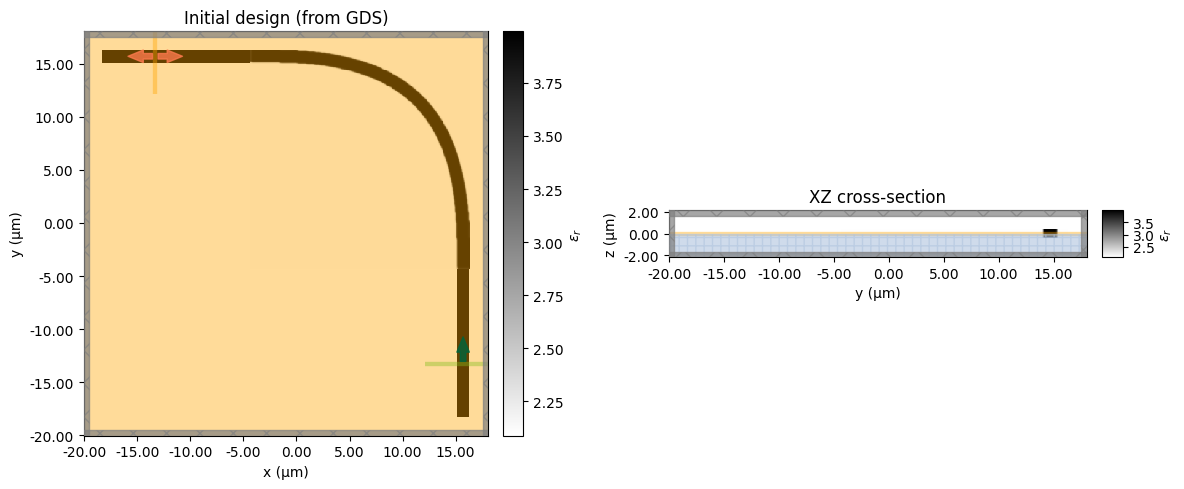

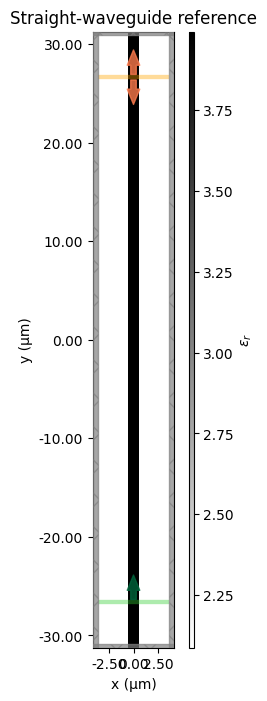

22:58:31 UTC Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=369477;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3f1fbd2c-ae32-43fa-9394-21270480b3f4\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=307344;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3f1fbd2c-ae32-43fa-9394-21270480b3f4\taskId]8;;\]8;id=369477;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3f1fbd2c-ae32-43fa-9394-21270480b3f4\=]8;;\]8;id=467003;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3f1fbd2c-ae32-43fa-9394-21270480b3f4\fdve]8;;\]8;id=369477;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3f1fbd2c-ae32-43fa-9394-21270480b3f4\-3f1fbd2c-ae3]8;;\
             ]8;id=369477;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3f1fbd2c-ae32-43fa-9394-21270480b3f4\2-43fa-9394-21270480b3f4']8;;\.

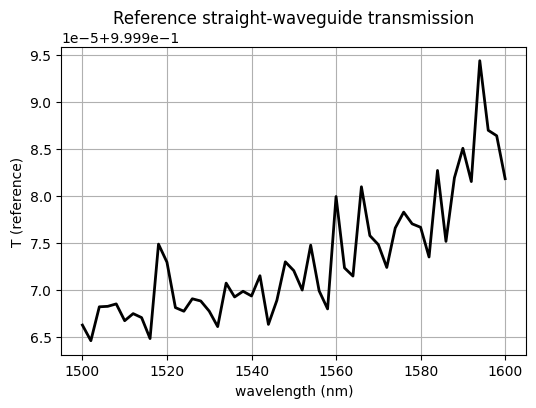

Reference T range across the sweep: 1.0000 to 1.0000


22:58:32 UTC Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=131926;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c9060f53-0cf1-4c2f-9f5d-3bfe8cdb80c3\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=780554;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c9060f53-0cf1-4c2f-9f5d-3bfe8cdb80c3\taskId]8;;\]8;id=131926;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c9060f53-0cf1-4c2f-9f5d-3bfe8cdb80c3\=]8;;\]8;id=501385;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c9060f53-0cf1-4c2f-9f5d-3bfe8cdb80c3\fdve]8;;\]8;id=131926;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c9060f53-0cf1-4c2f-9f5d-3bfe8cdb80c3\-c9060f53-0cf]8;;\
             ]8;id=131926;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c9060f53-0cf1-4c2f-9f5d-3bfe8cdb80c3\1-4c2f-9f5d-3bfe8cdb80c3']8;;\.

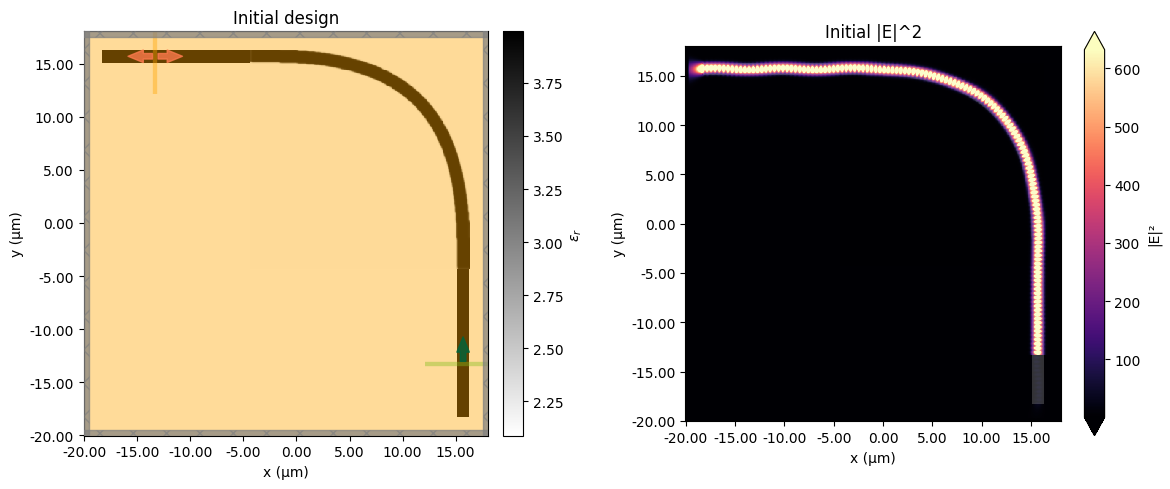

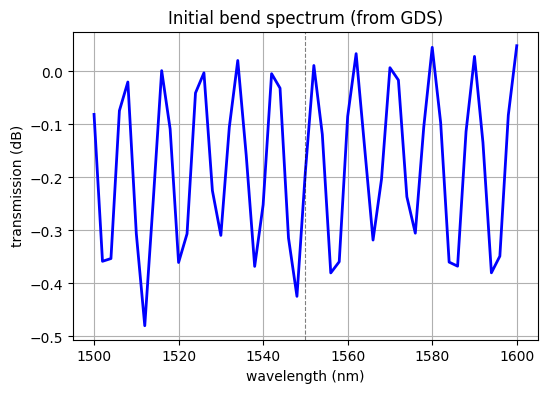

Initial design T @ 1550 nm: 0.9576 (-0.188 dB)


In [13]:
# =============================================================================
# 7. SANITY CHECK: RUN THE INITIAL DESIGN ONCE
# =============================================================================
 
# Visualize the base simulation + initial design before starting the optimizer.
sim_init = get_sim(params_init, beta=5.0, with_field_monitor=True)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
sim_init.plot_eps(z=0.0, ax=ax1)
ax1.set_title("Initial design (from GDS)")
sim_init.plot_eps(x=design_center[0], ax=ax2)
ax2.set_title("XZ cross-section")
plt.show()
 
# --- Broadband run of the initial design, so we can compare it to the
#     optimized design at the very end of this notebook on the same axis.
wvl_sweep = np.linspace(1.50, 1.60, 51)
freqs_sweep = td.C_0 / wvl_sweep
mode_monitor_bb = mode_monitor.updated_copy(freqs=list(freqs_sweep))

# =============================================================================
# REFERENCE RUN: straight waveguide for T-normalization
# =============================================================================
# One extra broadband FDTD on a straight Si3N4 waveguide of comparable
# length.  Dividing the bend's T by the straight-guide's T cancels out
# source-launch normalization errors, mode-plane truncation, PML artifacts,
# and numerical dispersion -- all the effects that let T drift above 1.

# Path length of the bend's fundamental mode, from source plane to monitor
# plane, traveled along the GDS centerline.  For a 90-deg bend of radius
# ~15.7 um plus the two stub sections inside the simulation domain:
r_bend = 15.7
path_straight_in  = (in_y  - sim_ymin) - buffer            # from src to arc
path_straight_out = (sim_xmax - out_x) - buffer            # from arc to mon
path_arc          = (np.pi / 2.0) * r_bend                 # 90-deg arc length
ref_length        = path_straight_in + path_arc + path_straight_out

# Build a long straight waveguide running along +y, centered on x=0.
ref_y_min = -ref_length / 2.0 - 2.0
ref_y_max =  ref_length / 2.0 + 2.0
ref_wg_poly = np.array([
    [-wg_width / 2.0, ref_y_min],
    [-wg_width / 2.0, ref_y_max],
    [ wg_width / 2.0, ref_y_max],
    [ wg_width / 2.0, ref_y_min],
])
ref_structure = polygon_to_structure(ref_wg_poly, SiN)

# Source and monitor planes sit `port_offset` inside each end.
ref_src = mode_source.updated_copy(
    center=(0.0, -ref_length / 2.0 + port_offset, 0.0),
    size=(mode_plane_w, 0.0, mode_plane_h),
)
ref_mon = mode_monitor_bb.updated_copy(
    center=(0.0,  ref_length / 2.0 - port_offset, 0.0),
    size=(mode_plane_w, 0.0, mode_plane_h),      # normal to y, so size_y = 0
    name="mode_ref",
)

# Tight simulation domain around the straight waveguide.
sim_ref = td.Simulation(
    center=(0.0, 0.0, 0.0),
    size=(4.0 * wg_width + 2.0 * buffer,
          ref_length + 2.0 * buffer,
          thick + 2.0 * buffer),
    run_time=80.0 / fwidth,
    structures=[ref_structure],
    sources=[ref_src],
    monitors=[ref_mon],
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=SiO2,
    symmetry=(0, 0, 1),                  # <-- add
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=min_steps_per_wvl,
        wavelength=wvl0,
    ),
)

# Visual sanity check before running.
fig, ax = plt.subplots(figsize=(4, 8))
sim_ref.plot_eps(z=0.0, ax=ax)
ax.set_title("Straight-waveguide reference")
plt.show()

data_ref = web.run(sim_ref, task_name="bend_straight_ref")

# Reference transmission (mode propagates in +y, so direction="+").
T_ref = np.abs(data_ref["mode_ref"].amps.sel(direction="+").values) ** 2
T_ref = T_ref.squeeze()

plt.figure(figsize=(6, 4))
plt.plot(wvl_sweep * 1e3, T_ref, "k", lw=2)
plt.xlabel("wavelength (nm)")
plt.ylabel("T (reference)")
plt.title("Reference straight-waveguide transmission")
plt.grid(True)
plt.show()

print(f"Reference T range across the sweep: "
      f"{T_ref.min():.4f} to {T_ref.max():.4f}")

# =============================================================================
 
sim_init_bb = sim_init.updated_copy(monitors=(mode_monitor_bb, field_monitor))
data_init = web.run(sim_init_bb, task_name="bend_initial")
 
# Field + eps plots at the design wavelength.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
sim_init.plot_eps(z=0, ax=axes[0])
axes[0].set_title("Initial design")
data_init.plot_field("field", "E", "abs^2", z=0, ax=axes[1])
axes[1].set_title("Initial |E|^2")
plt.show()
 
# Broadband transmission spectrum of the initial design.
T_init_raw = np.abs(data_init["mode"].amps.sel(direction="-").values) ** 2
T_init = T_init_raw.squeeze() / T_ref     # normalized
T_init_dB = 10.0 * np.log10(T_init.squeeze() + 1e-12)
 
plt.figure(figsize=(6, 4))
plt.plot(wvl_sweep * 1e3, T_init_dB, "b", lw=2)
plt.axvline(wvl0 * 1e3, color="k", ls="--", lw=0.8, alpha=0.5)
plt.xlabel("wavelength (nm)")
plt.ylabel("transmission (dB)")
plt.title("Initial bend spectrum (from GDS)")
plt.grid(True)
plt.show()
 
# Report the design-wavelength transmission for the initial design.
idx0_init = int(np.argmin(np.abs(wvl_sweep - wvl0)))
print(f"Initial design T @ 1550 nm: {T_init.squeeze()[idx0_init]:.4f} "
      f"({T_init_dB[idx0_init]:.3f} dB)")

In [14]:
# =============================================================================
# 8. OPTIMIZATION LOOP
# =============================================================================

num_steps = 50          # keep modest to control FlexCredit spend
learning_rate = 0.05    # smaller LR works better when starting near a good design

# Ramp beta (projection strength) over the course of optimization.
beta_min = 5.0
beta_max = 40.0

# --- Estimate FlexCredit cost before running any FDTD ---
task_id = web.upload(sim_init, task_name="bend_cost_estimate", verbose=False)
cost_per_sim = web.estimate_cost(task_id, verbose=True)
print(f"Cost per simulation:    {cost_per_sim:.3f} FlexCredits")
# Each optimization step runs one forward + one adjoint simulation (~2x cost).
print(f"Est. cost per opt step: {2 * cost_per_sim:.3f} FlexCredits")
print(f"Est. total ({num_steps} steps): {2 * cost_per_sim * num_steps:.3f} FlexCredits")

# Optionally delete the uploaded task so it doesn't clutter your workspace:
web.delete(task_id)

22:58:42 UTC Estimated FlexCredit cost: 2.971. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Cost per simulation:    2.971 FlexCredits
Est. cost per opt step: 5.941 FlexCredits
Est. total (50 steps): 297.062 FlexCredits


TaskInfo(taskId='fdve-c032cae0-6f5d-4940-bd25-06cdf29c2e9c', taskName='bend_cost_estimate', nodeSize=60471300, completedAt=None, status='draft', realCost=None, timeSteps=71267, solverVersion='release-26.2.1', createAt=None, estCostMin=0.0, estCostMax=0.0, realFlexUnit=0.0, oriRealFlexUnit=None, estFlexUnit=2.9706249954615647, estFlexCreditTimeStepping=0.0, estFlexCreditPostProcess=0.0, estFlexCreditMode=0.0, s3Storage=80929.0, startSolverTime=None, finishSolverTime=None, totalSolverTime=0, callbackUrl=None, taskType=None, metadataStatus='success', taskBlockInfo=None, version='v1')

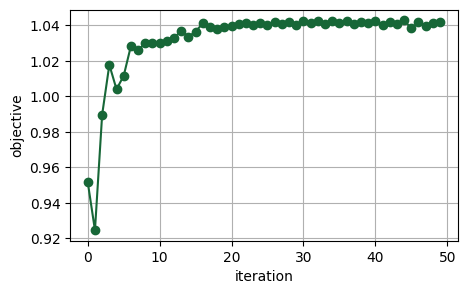

In [15]:
def get_beta(step):
    return beta_min + (beta_max - beta_min) * step / max(1, num_steps - 1)


optimizer = adam(learning_rate=learning_rate)
opt_state = optimizer.init(params_init)
params = params_init.copy()

objective_history = []
param_history = [params.copy()]

print("\nStarting optimization...")

for i in range(num_steps):
    beta = get_beta(i)

    # --- show current design before the FDTD run ---
    sim_i = get_sim(params, beta=beta)
    fig, ax = plt.subplots(figsize=(4, 4))
    sim_i.plot_eps(z=0.0, ax=ax, monitor_alpha=0.0, source_alpha=0.0)
    ax.set_title(f"step {i+1}  beta={beta:.1f}")
    plt.axis("off")
    plt.show()

    value, gradient = val_grad_fn(params, beta=beta)

    grad_norm = np.linalg.norm(gradient)
    print(f"step {i+1:3d}/{num_steps}  beta={beta:5.2f}  "
          f"J={value:.4f}  |grad|={grad_norm:.3e}")

    # Ascend the objective (minimize -J).
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params = apply_updates(params, updates)
    params = np.clip(params, 0.0, 1.0)

    objective_history.append(float(value))
    
    # live objective curve
    from IPython.display import clear_output
    clear_output(wait=True)
    plt.figure(figsize=(5, 3))
    plt.plot(objective_history, "-o")
    plt.xlabel("iteration"); plt.ylabel("objective")
    plt.grid(True); plt.show()
    param_history.append(params.copy())

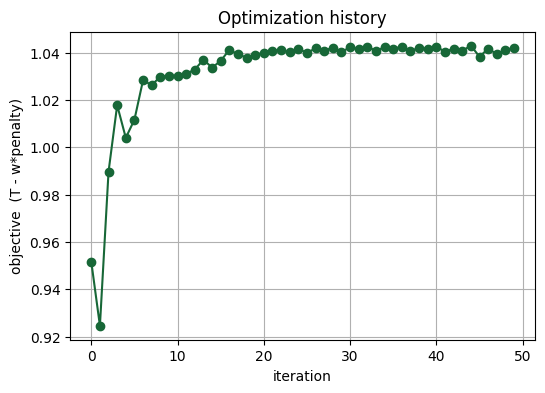

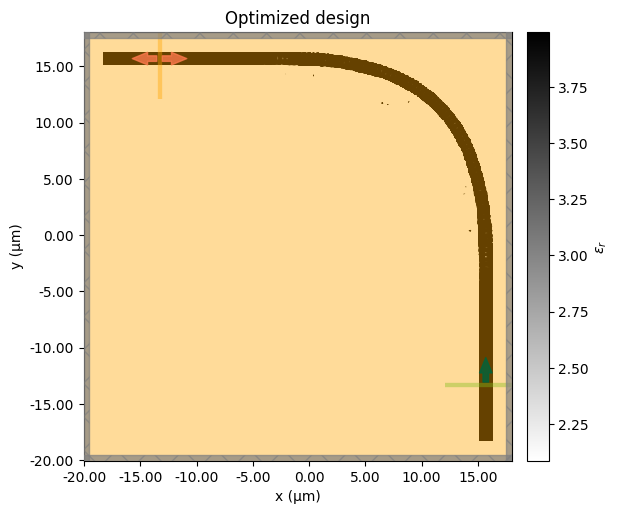

23:15:56 UTC Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=134181;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6ee43543-881c-4c4d-a197-26b5ecd4cfbf\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=224456;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6ee43543-881c-4c4d-a197-26b5ecd4cfbf\taskId]8;;\]8;id=134181;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6ee43543-881c-4c4d-a197-26b5ecd4cfbf\=]8;;\]8;id=780853;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6ee43543-881c-4c4d-a197-26b5ecd4cfbf\fdve]8;;\]8;id=134181;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6ee43543-881c-4c4d-a197-26b5ecd4cfbf\-6ee43543-881]8;;\
             ]8;id=134181;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6ee43543-881c-4c4d-a197-26b5ecd4cfbf\c-4c4d-a197-26b5ecd4cfbf']8;;\.

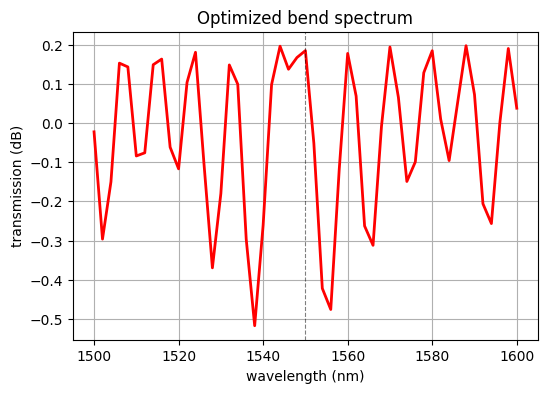

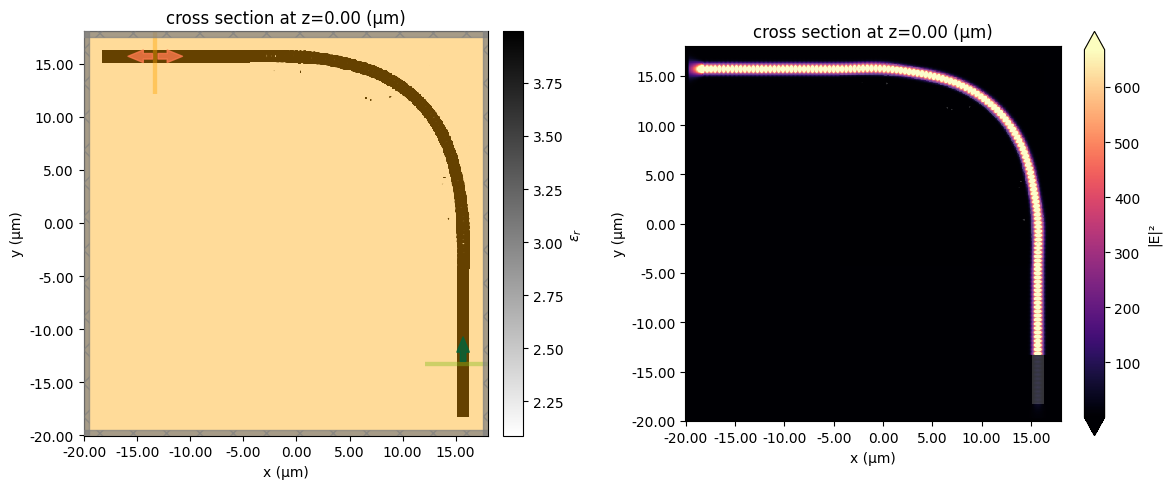

In [24]:
# =============================================================================
# 9. ANALYZE THE FINAL DESIGN
# =============================================================================
 
plt.figure(figsize=(6, 4))
plt.plot(objective_history, "-o")
plt.xlabel("iteration")
plt.ylabel("objective  (T - w*penalty)")
plt.title("Optimization history")
plt.grid(True)
plt.show()
 
params_final = param_history[-1]
sim_final = get_sim(params_final, beta=beta_max, with_field_monitor=True)
 
fig, ax = plt.subplots(figsize=(6, 6))
sim_final.plot_eps(z=0.0, ax=ax)
ax.set_title("Optimized design")
plt.show()
 
# Broadband performance: reuse the multi-frequency mode monitor defined in
# Section 7 so the initial and final designs are evaluated on the exact
# same wavelength grid.
sim_final_bb = sim_final.updated_copy(
    monitors=(mode_monitor_bb, field_monitor)
)
 
data_final = web.run(sim_final_bb, task_name="bend_final")
 
T_final_raw = np.abs(data_final["mode"].amps.sel(direction="-").values) ** 2
T_final = T_final_raw.squeeze() / T_ref.squeeze()   # normalized
T_final_dB = 10.0 * np.log10(T_final.squeeze() + 1e-12)
 
plt.figure(figsize=(6, 4))
plt.plot(wvl_sweep * 1e3, T_final_dB, "r", lw=2)
plt.axvline(wvl0 * 1e3, color="k", ls="--", lw=0.8, alpha=0.5)
plt.xlabel("wavelength (nm)")
plt.ylabel("transmission (dB)")
plt.title("Optimized bend spectrum")
plt.grid(True)
plt.show()
 
# Field plot at the design wavelength.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
sim_final.plot_eps(z=0.0, ax=ax1)
data_final.plot_field("field", "E", "abs^2", z=0.0, ax=ax2)
plt.show()

COMPARISON AT 1550 nm
Initial design:    T = 0.9576   IL = 0.188 dB
Optimized design:  T = 1.0436   IL = -0.185 dB
Improvement:       Delta-IL = +0.373 dB  (T ratio = 1.09x)

Average T across 1500-1600 nm:
  initial   = -0.178 dB
  optimized = -0.033 dB

1-dB bandwidth (within 1 dB of each design's own peak):
  initial   = 100.0 nm  (from 1500.0 to 1600.0 nm)
  optimized = 100.0 nm  (from 1500.0 to 1600.0 nm)


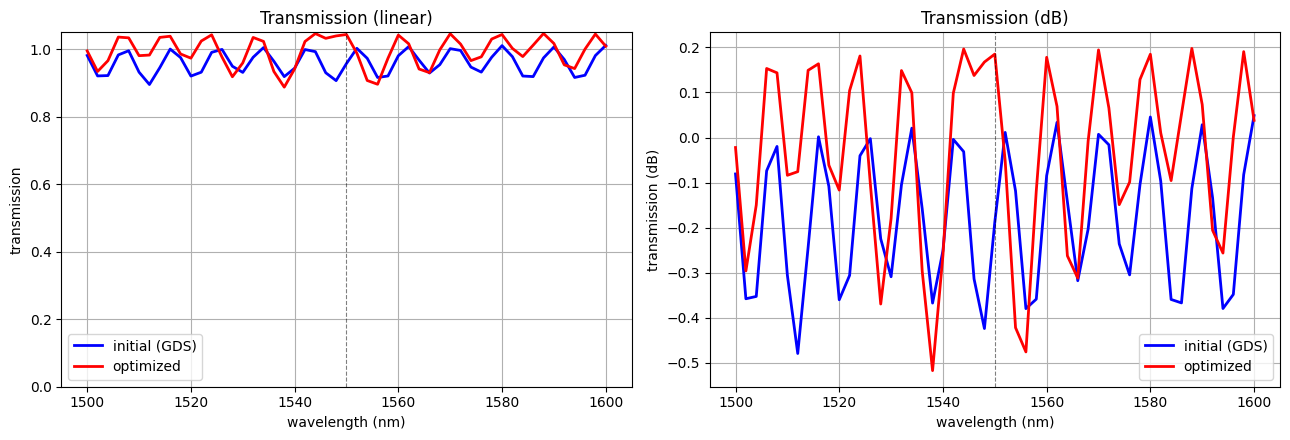

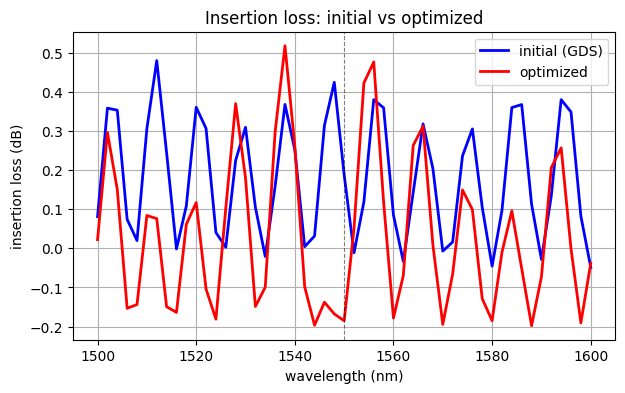

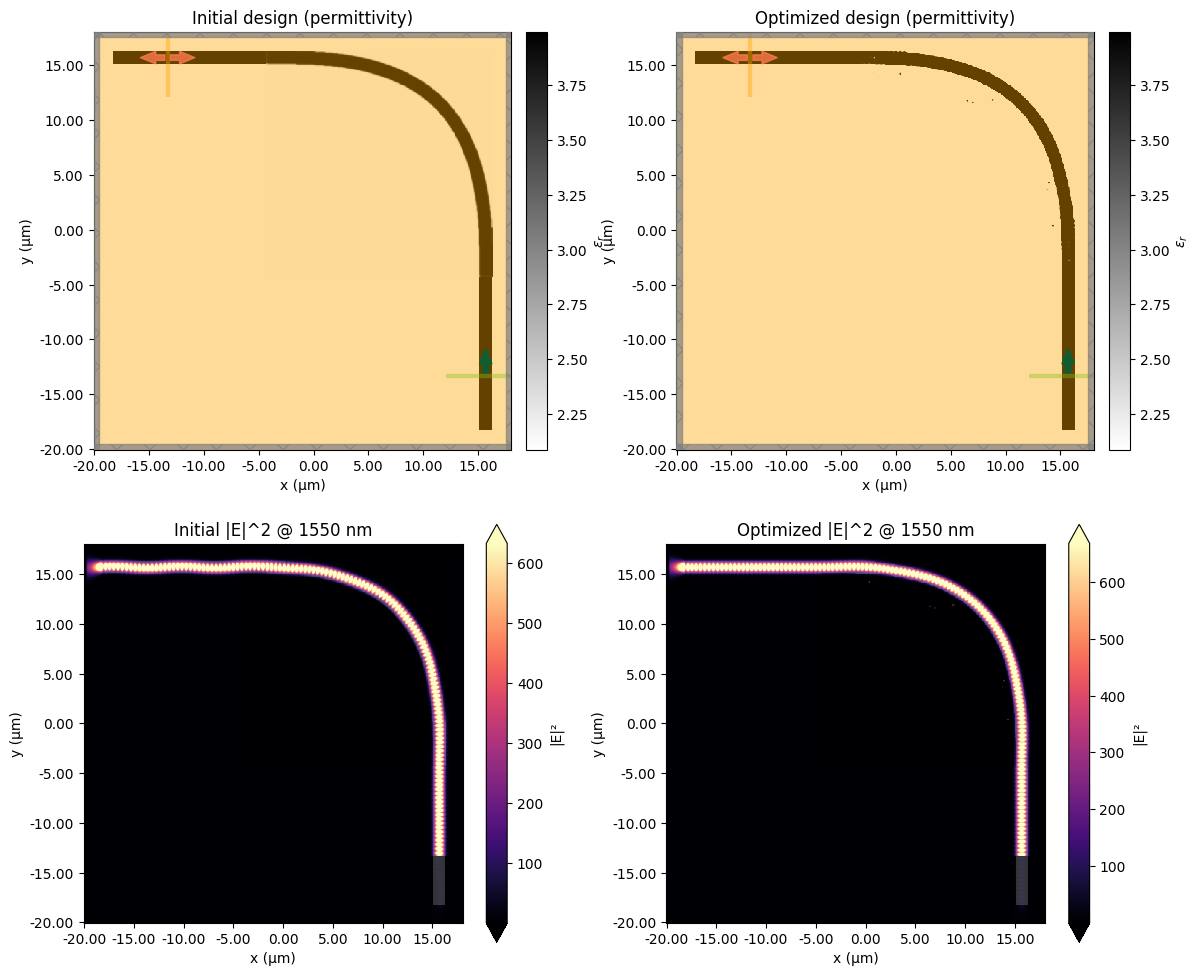

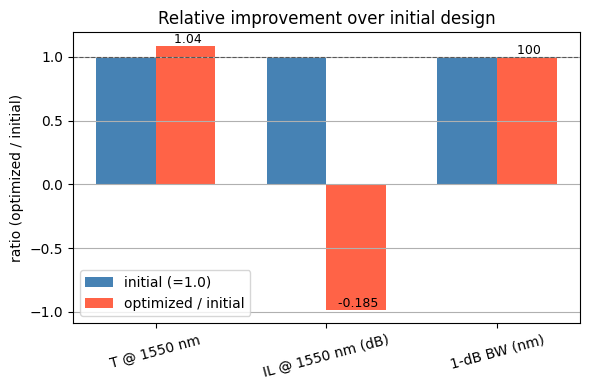

In [17]:
# =============================================================================
# 10. COMPARISON: INITIAL vs OPTIMIZED DESIGN
# =============================================================================
#
# We already have:
#   * data_init  -- broadband FDTD of the initial (from-GDS) bend
#   * data_final -- broadband FDTD of the optimized bend
# both evaluated on the same wavelength grid `wvl_sweep`.
# Here we assemble a full set of comparison plots and scalar metrics.
 
# --- Scalar metrics at the design wavelength (1550 nm) --------------------
idx0 = int(np.argmin(np.abs(wvl_sweep - wvl0)))
 
T_init_lin = float(T_init.squeeze()[idx0])
T_final_lin = float(T_final.squeeze()[idx0])
 
IL_init_dB = -10.0 * np.log10(T_init_lin + 1e-12)    # insertion loss (dB)
IL_final_dB = -10.0 * np.log10(T_final_lin + 1e-12)
dIL_dB = IL_init_dB - IL_final_dB                    # improvement (positive = better)
 
# Average transmission across the full C-band window we swept.
T_init_avg_dB = float(np.mean(10.0 * np.log10(T_init.squeeze() + 1e-12)))
T_final_avg_dB = float(np.mean(10.0 * np.log10(T_final.squeeze() + 1e-12)))
 
# 1-dB bandwidth = wavelength span over which transmission stays within 1 dB
# of that design's best value.
def bandwidth_1dB(T_dB, wvl):
    peak = np.max(T_dB)
    good = wvl[T_dB >= peak - 1.0]
    return (good.min(), good.max(), good.max() - good.min()) if len(good) else (np.nan, np.nan, np.nan)
 
bw_init = bandwidth_1dB(T_init_dB, wvl_sweep)
bw_final = bandwidth_1dB(T_final_dB, wvl_sweep)
 
print("=" * 60)
print("COMPARISON AT 1550 nm")
print("=" * 60)
print(f"Initial design:    T = {T_init_lin:.4f}   "
      f"IL = {IL_init_dB:.3f} dB")
print(f"Optimized design:  T = {T_final_lin:.4f}   "
      f"IL = {IL_final_dB:.3f} dB")
print(f"Improvement:       Delta-IL = {dIL_dB:+.3f} dB  "
      f"(T ratio = {T_final_lin / max(T_init_lin, 1e-12):.2f}x)")
print()
print(f"Average T across 1500-1600 nm:")
print(f"  initial   = {T_init_avg_dB:.3f} dB")
print(f"  optimized = {T_final_avg_dB:.3f} dB")
print()
print(f"1-dB bandwidth (within 1 dB of each design's own peak):")
print(f"  initial   = {bw_init[2]*1e3:.1f} nm  "
      f"(from {bw_init[0]*1e3:.1f} to {bw_init[1]*1e3:.1f} nm)")
print(f"  optimized = {bw_final[2]*1e3:.1f} nm  "
      f"(from {bw_final[0]*1e3:.1f} to {bw_final[1]*1e3:.1f} nm)")
print("=" * 60)
 
 
# --- Plot 1: transmission spectra overlay ---------------------------------
fig, (ax_lin, ax_db) = plt.subplots(1, 2, figsize=(13, 4.5), tight_layout=True)
 
ax_lin.plot(wvl_sweep * 1e3, T_init.squeeze(), "b", lw=2, label="initial (GDS)")
ax_lin.plot(wvl_sweep * 1e3, T_final.squeeze(), "r", lw=2, label="optimized")
ax_lin.axvline(wvl0 * 1e3, color="k", ls="--", lw=0.8, alpha=0.5)
ax_lin.set_xlabel("wavelength (nm)")
ax_lin.set_ylabel("transmission")
ax_lin.set_title("Transmission (linear)")
ax_lin.set_ylim(0, 1.05)
ax_lin.grid(True)
ax_lin.legend()
 
ax_db.plot(wvl_sweep * 1e3, T_init_dB, "b", lw=2, label="initial (GDS)")
ax_db.plot(wvl_sweep * 1e3, T_final_dB, "r", lw=2, label="optimized")
ax_db.axvline(wvl0 * 1e3, color="k", ls="--", lw=0.8, alpha=0.5)
ax_db.set_xlabel("wavelength (nm)")
ax_db.set_ylabel("transmission (dB)")
ax_db.set_title("Transmission (dB)")
ax_db.grid(True)
ax_db.legend()
 
plt.show()
 
 
# --- Plot 2: insertion loss comparison ------------------------------------
IL_init_curve = -T_init_dB
IL_final_curve = -T_final_dB
 
plt.figure(figsize=(7, 4))
plt.plot(wvl_sweep * 1e3, IL_init_curve, "b", lw=2, label="initial (GDS)")
plt.plot(wvl_sweep * 1e3, IL_final_curve, "r", lw=2, label="optimized")
plt.axvline(wvl0 * 1e3, color="k", ls="--", lw=0.8, alpha=0.5)
plt.xlabel("wavelength (nm)")
plt.ylabel("insertion loss (dB)")
plt.title("Insertion loss: initial vs optimized")
plt.grid(True)
plt.legend()
plt.show()
 
 
# --- Plot 3: side-by-side permittivity and field at 1550 nm ---------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), tight_layout=True)
 
sim_init.plot_eps(z=0.0, ax=axes[0, 0])
axes[0, 0].set_title("Initial design (permittivity)")
 
sim_final.plot_eps(z=0.0, ax=axes[0, 1])
axes[0, 1].set_title("Optimized design (permittivity)")
 
data_init.plot_field("field", "E", "abs^2", z=0.0, ax=axes[1, 0],
                     f=float(td.C_0 / wvl0))
axes[1, 0].set_title(f"Initial |E|^2 @ {wvl0*1e3:.0f} nm")
 
data_final.plot_field("field", "E", "abs^2", z=0.0, ax=axes[1, 1],
                      f=float(td.C_0 / wvl0))
axes[1, 1].set_title(f"Optimized |E|^2 @ {wvl0*1e3:.0f} nm")
 
plt.show()
 
 
# --- Plot 4: bar chart of key metrics -------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["T @ 1550 nm", "IL @ 1550 nm (dB)", "1-dB BW (nm)"]
init_vals = [T_init_lin, IL_init_dB, bw_init[2] * 1e3]
final_vals = [T_final_lin, IL_final_dB, bw_final[2] * 1e3]
 
# Put each metric on its own axis by normalizing to the initial value, so
# they fit on one chart regardless of units.
x = np.arange(len(labels))
w = 0.35
# Normalize so the initial bar is always 1.0.
norm_init = [1.0 for _ in init_vals]
norm_final = [f / i if i != 0 else 0 for f, i in zip(final_vals, init_vals)]
 
ax.bar(x - w/2, norm_init, w, label="initial (=1.0)", color="steelblue")
ax.bar(x + w/2, norm_final, w, label="optimized / initial", color="tomato")
ax.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("ratio (optimized / initial)")
ax.set_title("Relative improvement over initial design")
ax.grid(True, axis="y")
ax.legend()
 
# Annotate each optimized bar with the raw value.
for xi, val, raw in zip(x + w/2, norm_final, final_vals):
    ax.text(xi, val, f" {raw:.3g}", ha="center", va="bottom", fontsize=9)
 
plt.tight_layout()
plt.show()
 

In [29]:
# Uncomment to export the optimized layout to GDS.

data_final = td.SimulationData.from_file("simulation_data.hdf5")
sim_final = data_final.simulation

sim_final.to_gds_file(
     fname="./optimized_bend2.gds",
     z=0.0,
     frequency=freq0,
     permittivity_threshold=(eps_sin + eps_sio2) / 2.0,
)